In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# raw_coco = tfds.load("coco/2017",
#                      split="train[:5%]",
#                      as_supervised=False,
#                      data_dir = "/content/new_coco_storage",
#                      download=True
#                      )

# print("COCO loaded")

In [5]:
# IMG_SIZE=128

# def make_training_pair(example):

#       color_image = example['image']
#       color_image = tf.image.resize (
#           color_image,
#           (IMG_SIZE, IMG_SIZE),
#       )

#       color_image = tf.cast(color_image,tf.float32)/255.0
#       gray_image = tf.image.rgb_to_grayscale(color_image)

#       return gray_image,color_image

# processed_coco = raw_coco.map(
#     make_training_pair,
#     num_parallel_calls = tf.data.AUTOTUNE
# )


# print("Preprocessing complete")

In [6]:
# processed_coco.save(
#     "/content/drive/MyDrive/my_new_color_dataset"
# )

# print("Dataset saved")

In [7]:
training_data = tf.data.Dataset.load(
     "/content/drive/MyDrive/my_new_color_dataset"
)

training_data = training_data.shuffle(1000)
training_data = training_data.batch(32)

training_data = training_data.prefetch(
    tf.data.AUTOTUNE
)

print("Dataset loaded")

Dataset loaded


In [8]:
inputs = tf.keras.Input(shape=(128,128,1))



e1 = layers.Conv2D(
    32,
    3,
    padding='same'
)(inputs)

e1 = layers.BatchNormalization()(e1)
e1 = layers.ReLU()(e1)

e1 = layers.Conv2D(
    32,
    3,
    padding='same'
)(e1)

e1 = layers.BatchNormalization()(e1)
e1 = layers.ReLU()(e1)

m1 = layers.MaxPooling2D()(e1)




e2 = layers.Conv2D(
    64,
    3,
    padding='same'
)(m1)

e2 = layers.BatchNormalization()(e2)
e2 = layers.ReLU()(e2)

e2 = layers.Conv2D(
    64,
    3,
    padding='same'
)(e2)

e2 = layers.BatchNormalization()(e2)
e2 = layers.ReLU()(e2)

m2 = layers.MaxPooling2D()(e2)





middle = layers.Conv2D(
    128,
    3,
    padding='same'
)(m2)

middle = layers.BatchNormalization()(middle)
middle = layers.ReLU()(middle)

middle = layers.Conv2D(
    128,
    3,
    padding='same'
)(middle)

middle = layers.BatchNormalization()(middle)
middle = layers.ReLU()(middle)




d1 = layers.UpSampling2D()(middle)

d1 = layers.Concatenate()([d1,e2])

d1 = layers.Conv2D(
    64,
    3,
    padding='same'
)(d1)

d1 = layers.BatchNormalization()(d1)
d1 = layers.ReLU()(d1)

d1 = layers.Conv2D(
    64,
    3,
    padding='same'
)(d1)

d1 = layers.BatchNormalization()(d1)
d1 = layers.ReLU()(d1)




d2 = layers.UpSampling2D()(d1)

d2 = layers.Concatenate()([d2,e1])

d2 = layers.Conv2D(
    32,
    3,
    padding='same'
)(d2)

d2 = layers.BatchNormalization()(d2)
d2 = layers.ReLU()(d2)

d2 = layers.Conv2D(
    32,
    3,
    padding='same'
)(d2)

d2 = layers.BatchNormalization()(d2)
d2 = layers.ReLU()(d2)




outputs = layers.Conv2D(
    3,
    1,
    activation='sigmoid'
)(d2)



color_model = Model(inputs, outputs)




color_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='mse'
)




color_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 473,603 (1.81 MB)

 Trainable params: 472,323 (1.80 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [9]:


# history = color_model.fit(
#     training_data,
#     epochs=60
# )

# color_model.save(
#     "/content/drive/MyDrive/my_color_model.keras"
# )

# print("Model saved")

In [10]:
color_model = load_model(
    "/content/drive/MyDrive/my_color_model.keras"
)

print("Model loaded")

Model loaded


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


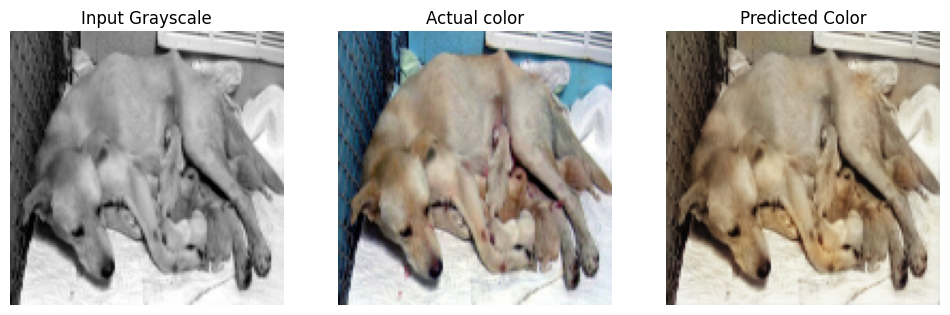

In [25]:
for gray,color in training_data.take(1):

  predicted = color_model.predict(gray[:1])
  plt.figure(figsize=(12,4))
  plt.subplot(1,3,1)
  plt.imshow(gray[0].numpy().squeeze(),cmap='gray')
  plt.title("Input Grayscale")
  plt.axis("off")

  plt.subplot(1,3,2)
  plt.imshow(color[0].numpy())
  plt.title("Actual color")
  plt.axis("off")

  plt.subplot(1,3,3)
  plt.imshow(
        predicted[0]
    )
  plt.title("Predicted Color")
  plt.axis("off")

  plt.show()

  break